In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [21]:
# read the titanic dataset
df = pd.read_csv('../csv/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
# So the objective is to predict the survival of passengers based on the features available in the dataset. The target variable is 'Survived', which is a binary variable indicating whether a passenger survived (1) or not (0).

In [23]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
mean_age = df['Age'].mean()

In [25]:
df['Age'] = df['Age'].fillna(mean_age)

In [26]:
mode_embarked = df['Embarked'].mode()[0]

In [27]:
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

In [28]:
df = pd.get_dummies(df.drop(['Name', 'Ticket', 'Cabin'], axis=1), dtype=int)

In [29]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,2,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,4,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,5,0,3,35.0,0,0,8.0500,0,1,0,0,1


In [30]:
# Now, let's segregate the feature and target variable.

In [31]:
x = df.drop('Survived', axis=1)
y = df['Survived']
print(x.shape, y.shape)

(891, 11) (891,)


In [32]:
# let's scale the features using StandardScaler.

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [34]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
# Let's implement the KNN algorithm using scikit-learn's KNeighborsClassifier.

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [37]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [39]:
train_pred = knn.predict(x_train)
f1_eval = f1_score(y_train, train_pred)
print(f"F1 score on training data: {f1_eval:.4f}")

F1 score on training data: 0.7984


In [40]:
# Fine, now let's use the elbow method to find the optimal value of K for our model.

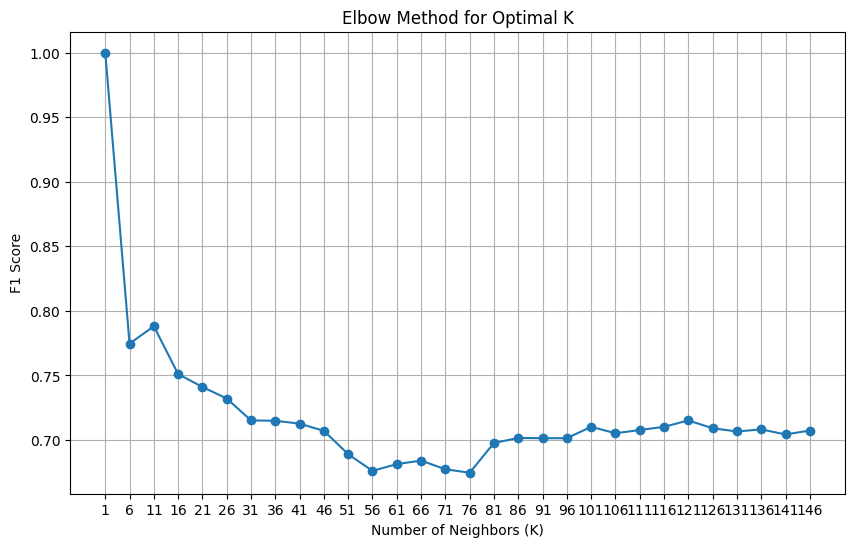

In [45]:
k_values = range(1, 150, 5)  # Using odd values of K to avoid ties
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    train_pred = knn.predict(x_train)
    f1_eval = f1_score(y_train, train_pred)
    f1_scores.append(f1_eval)

plt.figure(figsize=(10, 6))
plt.plot(k_values, f1_scores, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1 Score')
plt.xticks(k_values)
plt.grid()

In [46]:
# from the plot, we are seeing two values where min k can be found, one at 56 and other at 76

In [47]:
# Let's evaluate at k = 56 and k = 76

In [48]:
train_pred_56 = KNeighborsClassifier(n_neighbors=56).fit(x_train, y_train).predict(x_train)
f1_eval_56 = f1_score(y_train, train_pred_56)

train_pred_76 = KNeighborsClassifier(n_neighbors=76).fit(x_train, y_train).predict(x_train)
f1_eval_76 = f1_score(y_train, train_pred_76)
print(f"F1 score on training data at k=56: {f1_eval_56:.4f}")
print(f"F1 score on training data at k=76: {f1_eval_76:.4f}")

F1 score on training data at k=56: 0.6760
F1 score on training data at k=76: 0.6746


In [49]:
# Almost similar F1 scores are observed at k=56 and k=76. However, we will choose k=56 as it is the smaller value and will help in reducing the complexity of the model.

In [50]:
# Let's now evaluate the final preds!

In [ ]:
test_pred_56 = KNeighborsClassifier(n_neighbors=56).fit(x_train, y_train).predict(x_test)
f1_eval_test = f1_score(y_test, test_pred_56)

test_pred_5 = KNeighborsClassifier(n_neighbors=5).fit(x_train, y_train).predict(x_test)
f1_eval_test_5 = f1_score(y_test, test_pred_5)
print(f"F1 score on test data at k=56: {f1_eval_test:.4f}")
print(f"F1 score on test data at k=5: {f1_eval_test_5:.4f}")

F1 score on test data at k=56: 0.6891
F1 score on test data at k=5: 0.6825


In [52]:
# Let's implement k fold cross-validation to evaluate the model's performance more robustly.

In [53]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(KNeighborsClassifier(n_neighbors=5), x_scaled, y, cv=10, scoring='f1')
score

array([0.67741935, 0.74193548, 0.6779661 , 0.77922078, 0.75757576,
       0.73239437, 0.77419355, 0.56603774, 0.72727273, 0.75362319])

In [59]:
print(f"Mean F1 score: {score.mean()*100:.2f}", f"Standard deviation: {score.std()*100:.2f}")

Mean F1 score: 71.88 Standard deviation: 6.08


In [60]:
# Now, let's find the optimal value of K using cross-validation.

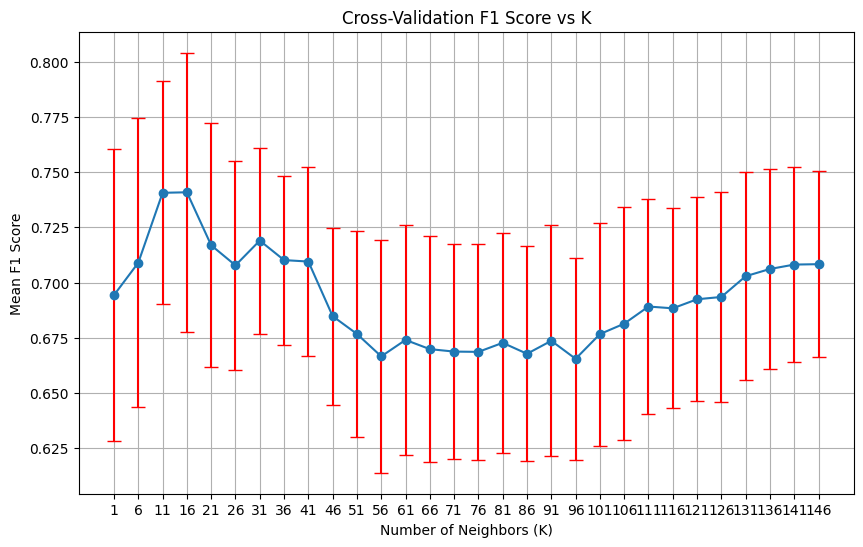

In [61]:
k_folds = range(1, 150, 5)

avg = []
std = []

for i in k_folds:
    knn = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(knn, x_scaled, y, cv=10, scoring='f1')
    avg.append(scores.mean())
    std.append(scores.std())

plt.figure(figsize=(10, 6))
plt.errorbar(k_folds, avg, yerr=std, fmt='-o', ecolor='r', capsize=5)
plt.title('Cross-Validation F1 Score vs K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean F1 Score')
plt.xticks(k_folds)
plt.grid()

In [62]:
# So, even the cross-validation results suggest that k=56 is the minimum value of K that would give us the best performance.